# Time Series Analysis

Time series data is a collection of quantities that are assembled over even intervals in time and ordered chronologically. The time interval at which data is collection is generally referred to as the time series frequency. Interesting questions are: 

* How do we deal with missing data? (last script)

* Are there seasonality pattern? For example in the time series of the temperature? 

* Does the data show some trends such that we could make assumptions about the future? 





## Seasonal decompositon

Time series data can exhibit a huge variety of temporal patterns. In many cases it is useful to categorize these patterns, and further,  split them up into distinct components. In general many time series can be decomposed into three parts:

* __Trend__: A trend exists when there is a long-term increase or decrease in the data. 
* __Seasonal pattern__:  A seasonal pattern exists when a series is influenced by seasonal factors. Seasonality is always of a fixed and known period.  
* __Residual__:  The remainder, after accounting for the trend and seasonality; also known as [noise](https://en.wikipedia.org/wiki/White_noise).

We can principally model such a time series in two ways: as an **additive model** and as a **multiplicative model**.


The additive model can be written as

$$y_t = T_t + S_t + E_t\text{,}$$

and the multiplicative model can be written as 

$$y_t = T_t \times S_t \times E_t\text{,}$$

where $y_t$ is the data at period $t$, $T_t$ is the trend-cycle component, $S_t$ is the seasonal component and $E_t$ is the remainder component at period $t$.


>The **additive model** is most appropriate if the magnitude of the seasonal fluctuations or the variation around the trend-cycle does not change with a trend of the time series. When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a **multiplicative mode** is more appropriate.

***

### Decomposition of the temperature time series


For the purpose of demonstration we look at the air temperature measured in Dahlem, Berlin. The data is downloaded from the open data center of the DWD (German Weather Service) https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/air_temperature/historical/. 
Dahlem has station ID 403, so we download stundenwerte_TU_00403_20020101_20241231_hist.zip in this directory. 
If you are interested in further variables, e.g., precipitation, take a look here: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/

The Data information: 
 

| Station ID | Start Date | End Date  | Station          | Parameter | Description                | Unit | Source                                                                 | Time Reference   |
|-------------|-------------|-----------|------------------|------------|-----------------------------|------|---------------------------------------------------------------------------|------------------|
| 403         | 20020101    | 20250514  | Berlin-Dahlem (FU) | RF_TU     | Relative humidity           | %    | Temperature and relative humidity (hourly values) generated from SYNOP reports (after 01.04.2001) | Hourly values in UTC |
| 403         | 20020101    | 20250514  | Berlin-Dahlem (FU) | TT_TU     | Air temperature             | °C   | Temperature and relative humidity (hourly values) generated from SYNOP reports (after 01.04.2001) | Hourly values in UTC |


We start with reading the data set as a pandas data frame:


In [284]:
import pandas as pd


df = pd.read_csv('./produkt_tu_stunde_20020101_20241231_00403.txt', sep=';')

In [285]:
df

,STATIONS_ID,MESS_DATUM,QN_9,TT_TU,RF_TU,eor
0,403,2002010100,3,-5.5,88.0,eor
1,403,2002010103,3,-3.7,86.0,eor
2,403,2002010106,3,-2.0,96.0,eor
3,403,2002010109,3,-0.4,92.0,eor
4,403,2002010112,3,0.6,86.0,eor
...,...,...,...,...,...,...
200524,403,2024123119,3,2.3,90.0,eor
200525,403,2024123120,3,2.5,88.0,eor
200526,403,2024123121,3,2.2,88.0,eor
200527,403,2024123122,3,2.2,86.0,eor


Next, we rename the variable MESS_Date to Date and set the date as the index. 

In [286]:
# Convert 'MESS_DATUM' to datetime format and set it as the index
df['Date'] = pd.to_datetime(df['MESS_DATUM'], format='%Y%m%d%H')
df.set_index('Date', inplace=True)
df


,STATIONS_ID,MESS_DATUM,QN_9,TT_TU,RF_TU,eor
Date,,,,,,
2002-01-01 00:00:00,403,2002010100,3,-5.5,88.0,eor
2002-01-01 03:00:00,403,2002010103,3,-3.7,86.0,eor
2002-01-01 06:00:00,403,2002010106,3,-2.0,96.0,eor
2002-01-01 09:00:00,403,2002010109,3,-0.4,92.0,eor
2002-01-01 12:00:00,403,2002010112,3,0.6,86.0,eor
...,...,...,...,...,...,...
2024-12-31 19:00:00,403,2024123119,3,2.3,90.0,eor
2024-12-31 20:00:00,403,2024123120,3,2.5,88.0,eor
2024-12-31 21:00:00,403,2024123121,3,2.2,88.0,eor


In [287]:
#drop unnecessary columns
df = df.drop(columns=['STATIONS_ID', 'MESS_DATUM', 'QN_9'])
df


,TT_TU,RF_TU,eor
Date,,,
2002-01-01 00:00:00,-5.5,88.0,eor
2002-01-01 03:00:00,-3.7,86.0,eor
2002-01-01 06:00:00,-2.0,96.0,eor
2002-01-01 09:00:00,-0.4,92.0,eor
2002-01-01 12:00:00,0.6,86.0,eor
...,...,...,...
2024-12-31 19:00:00,2.3,90.0,eor
2024-12-31 20:00:00,2.5,88.0,eor
2024-12-31 21:00:00,2.2,88.0,eor


Let us check the statistics. Do we need to clean the data set?

In [256]:
df.describe()

,TT_TU,RF_TU
count,200529.000000,200529.000000
mean,10.305015,76.303024
std,9.323284,23.125556
min,-999.000000,-999.000000
25%,4.200000,62.000000
50%,10.100000,81.000000
75%,16.200000,93.000000
max,37.500000,100.000000


It looks like there are NANs marked as -999 in this data set (see also the corresponding meta file). 
So we remove these values in the next step. Since we are working with hourly data, we use pythons forward fill of the past measurement. 

In [288]:

import numpy as np

df = df.replace('-999', np.nan)
df = df.replace(-999, np.nan)
df = df.ffill()

df.describe()




,TT_TU,RF_TU
count,200529.000000,200529.000000
mean,10.325179,76.465030
std,8.161074,19.022232
min,-19.300000,18.000000
25%,4.200000,62.000000
50%,10.100000,81.000000
75%,16.200000,93.000000
max,37.500000,100.000000


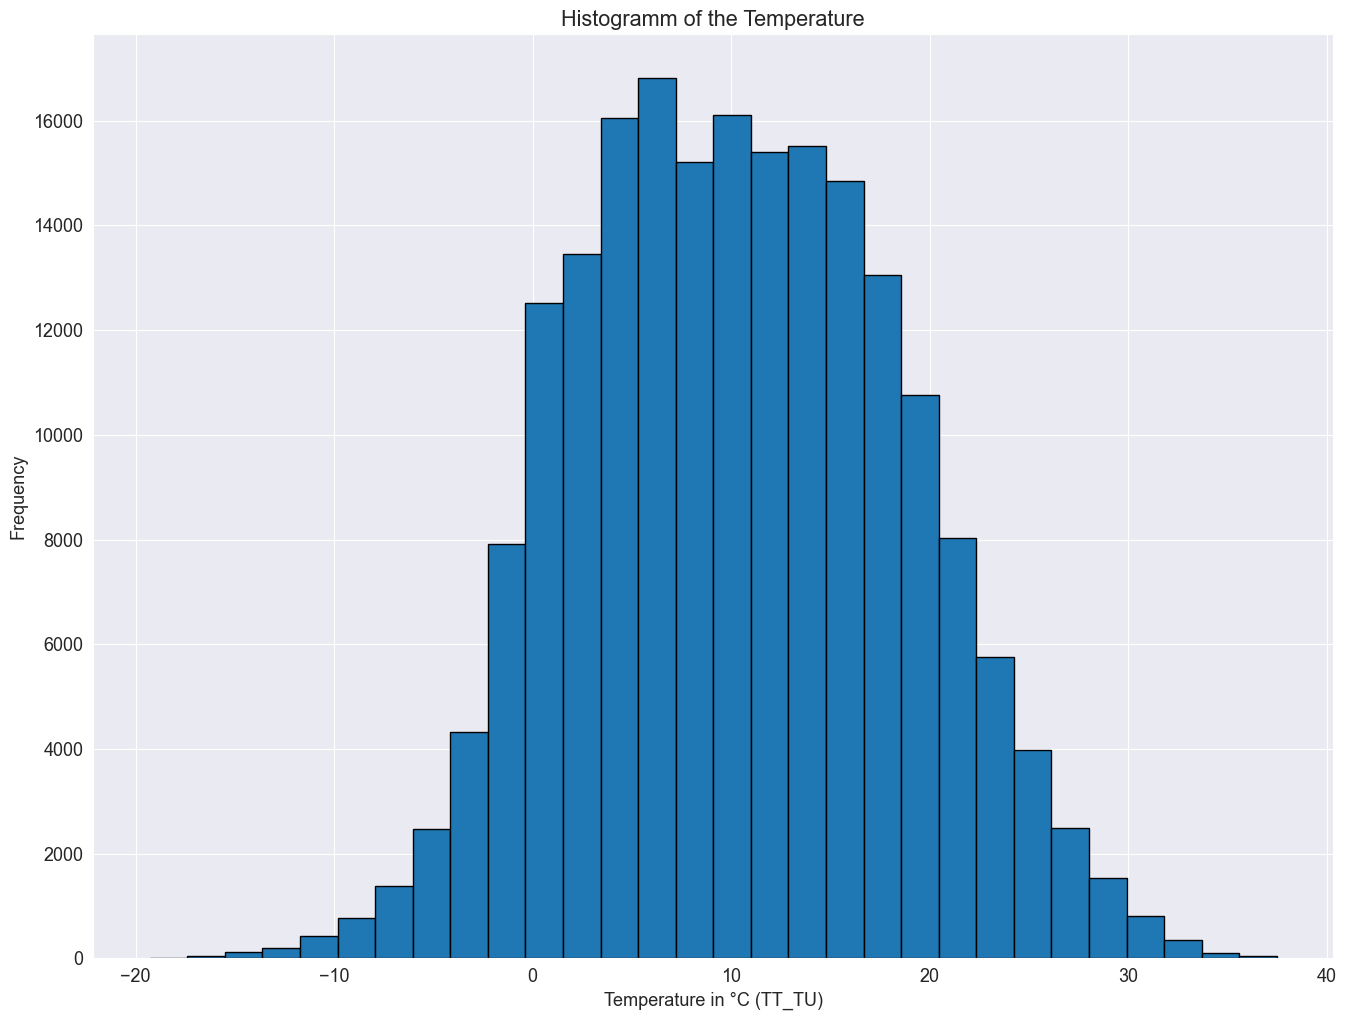

In [292]:

import numpy as np
import matplotlib.pyplot as plt

# Plot the histogram 
n, bins, patches = plt.hist((df['TT_TU']), bins=30, edgecolor='black')
plt.xlabel('Temperature in °C (TT_TU)')
plt.ylabel('Frequency')
plt.title('Histogramm of the Temperature')
plt.show()

In [290]:
df.describe()

,TT_TU,RF_TU
count,200529.000000,200529.000000
mean,10.325179,76.465030
std,8.161074,19.022232
min,-19.300000,18.000000
25%,4.200000,62.000000
50%,10.100000,81.000000
75%,16.200000,93.000000
max,37.500000,100.000000


The distribution is unimodal and symmetric, so we can calculate the arithmetic mean and the standard deviation and apply statistical analysis without data transformation. 



## STL decomposition

STL is an acronym for “Seasonal and Trend decomposition using Loess”, while loess (locally weighted regression and scatterplot smoothing) is a method for estimating nonlinear relationships.

In [261]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

In [262]:
register_matplotlib_converters()
sns.set_style('darkgrid')

In [263]:
plt.rc('figure',figsize=(16,12))
plt.rc('font',size=13)

In [291]:
# Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['TT_TU'], model='add', extrapolate_trend='freq')

ValueError: You must specify a period or x must be a pandas object with a PeriodIndex or a DatetimeIndex with a freq not set to None

Oh an error, we need to aggregate the daily data to monthly data.

In [293]:
df = df.asfreq('M',method='ffill')
df


,TT_TU,RF_TU,eor
Date,,,
2002-01-31,10.0,72.0,eor
2002-02-28,3.0,65.0,eor
2002-03-31,7.6,63.0,eor
2002-04-30,8.4,73.0,eor
2002-05-31,12.8,84.0,eor
...,...,...,...
2024-08-31,16.0,78.0,eor
2024-09-30,5.1,100.0,eor
2024-10-31,11.1,90.0,eor


In [294]:
df.describe()

,TT_TU,RF_TU
count,276.000000,276.000000
mean,8.257246,84.626812
std,6.762731,13.080528
min,-10.800000,39.000000
25%,3.300000,75.750000
50%,8.550000,88.000000
75%,13.300000,96.000000
max,23.000000,100.000000


### Additive Decomposition

In [295]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Time Series Decomposition
result = seasonal_decompose(df['TT_TU'], model='additive', extrapolate_trend='freq')


The result contains 4 different time series, given by the trend, the seasonal component, the residuals and the original time series. 

In [296]:
result.trend # trend component
result.seasonal # seasonal component
result.resid # residuals (rest)
result.observed # original time series

Date
2002-01-31    10.0
2002-02-28     3.0
2002-03-31     7.6
2002-04-30     8.4
2002-05-31    12.8
              ... 
2024-08-31    16.0
2024-09-30     5.1
2024-10-31    11.1
2024-11-30     4.3
2024-12-31    -0.4
Freq: M, Name: TT_TU, Length: 276, dtype: float64

These four time series can be plotted directly from the result object by calling the plot() function. For example:


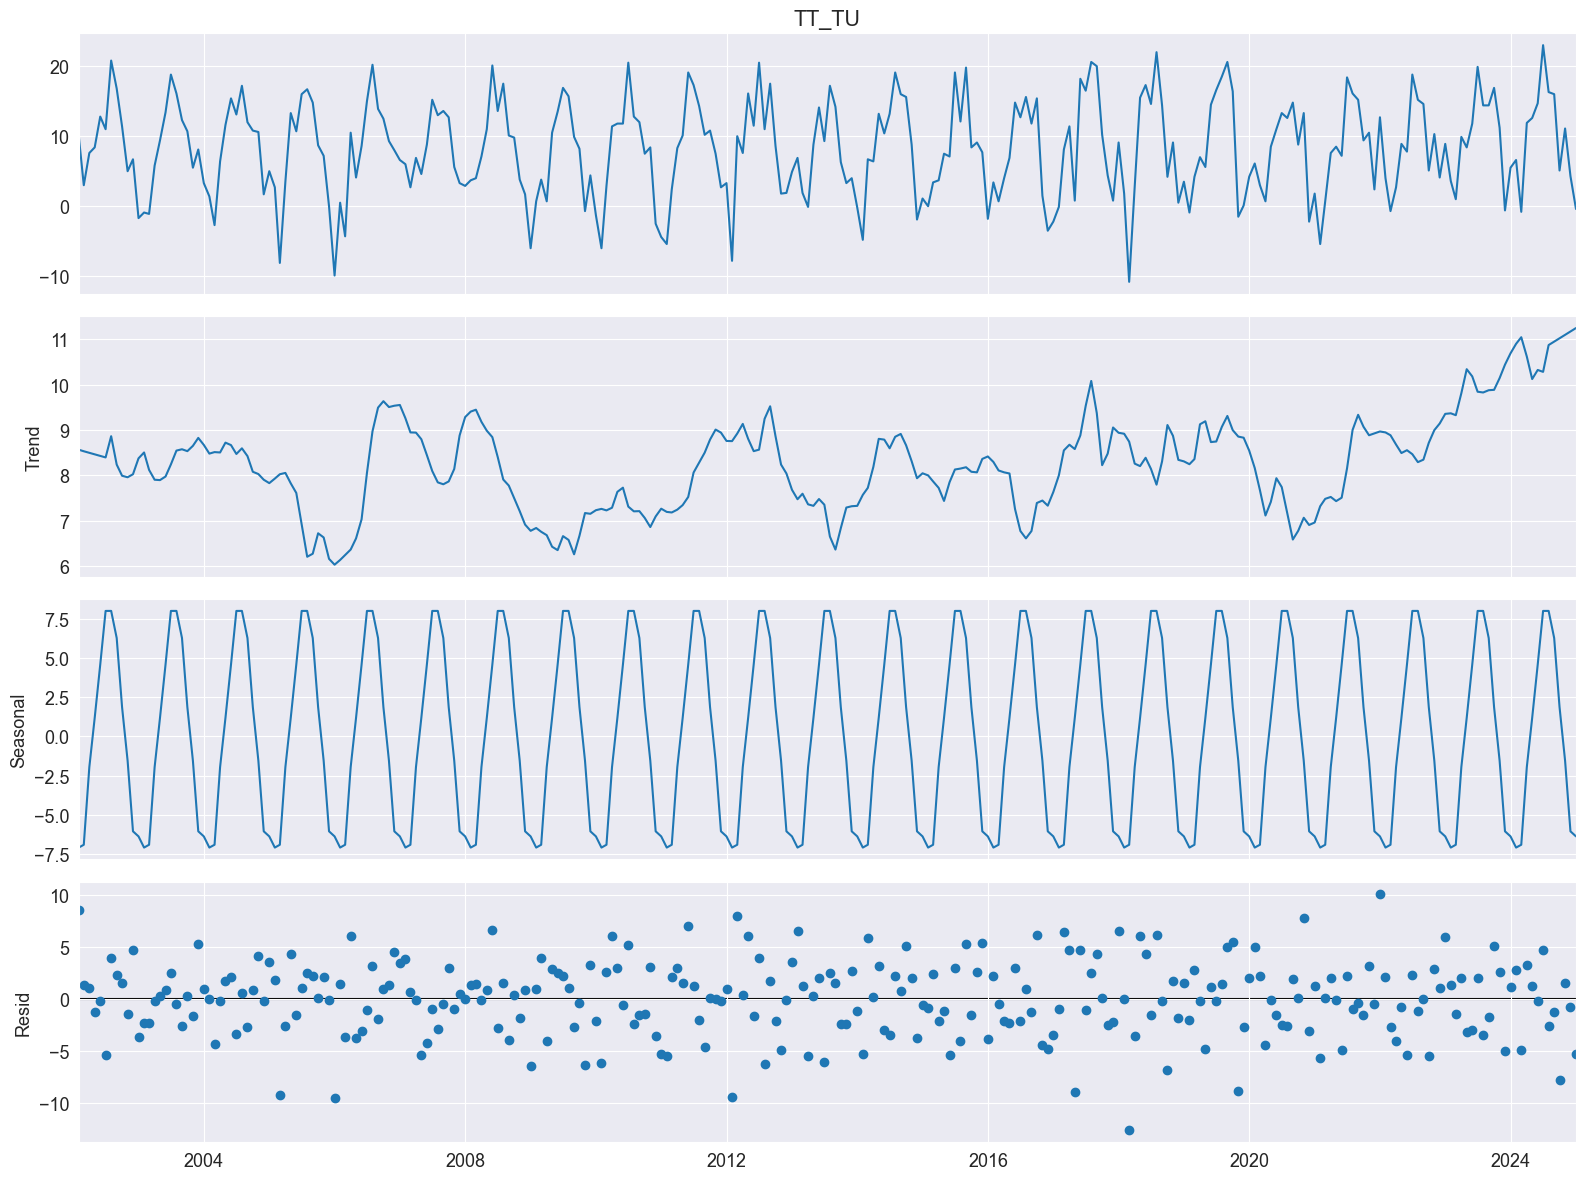

In [297]:
from matplotlib import pyplot
result.plot()
pyplot.show()

The plot shows four panels. In the uppermost we see the raw data of the temperature, where we might not recognize a clear positive trend during the time period 2021-2024. In the subsequent plot we see the trend component, the seasonal component and the remainder. 
The temperature increase is much better visible now. 
The remainder seems quite noisy and is devoid of a particular pattern. This indicates that the seasonal decomposition did a good job in extracting the trend and seasonal components

We can save the time series of the components in our data frame. 

In [271]:
# Save the components of the time series decomposition as new features in the DataFrame
df['trend'] = result.trend
df['seasonal'] = result.seasonal
df['resid'] = result.resid
df['observed'] = result.observed

df['STL sum'] = df['trend'] + df['seasonal'] + df['resid']

In [272]:
df.head(5)

,TT_TU,RF_TU,eor,trend,seasonal,resid,observed,STL sum
Date,,,,,,,,
2002-01-31,10.0,72.0,eor,8.565011,-7.101456,8.536446,10.0,10.0
2002-02-28,3.0,65.0,eor,8.531036,-6.920813,1.389776,3.0,3.0
2002-03-31,7.6,63.0,eor,8.497062,-1.958647,1.061585,7.6,7.6
2002-04-30,8.4,73.0,eor,8.463088,1.186671,-1.249758,8.4,8.4
2002-05-31,12.8,84.0,eor,8.429113,4.594488,-0.223602,12.8,12.8


We can also do the same for a shorter time period of the data set:

In [273]:
df_2000to2024 = df['2020-01-01':'2024-01-01']

>**Exercise 1**: <br> 
> Decompose the time series of the four years saved in the data frame df_2000to2024 


#### Multiplicative Decomposition

Let us check the multiplicative decomposition


In [274]:
# Time Series Decomposition
result_mult = seasonal_decompose(df['TT_TU'], model='multiplicative', extrapolate_trend='freq')

ValueError: Multiplicative seasonality is not appropriate for zero and negative values

Zero values of the temperature cause errors, since we multiply the components of the STL. As mentioned above, the **additive model** is most appropriate if the magnitude of the seasonal fluctuations or the variation around the trend-cycle does not change with a trend of the time series, which we recognize in our data set. When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a **multiplicative mode** is more appropriate.

### Decision Guide: Additive vs Multiplicative Decomposition

| Criterion | Additive | Multiplicative |
|-----------|----------|----------------|
| **Seasonal Amplitude** | Constant (e.g. ±10 units) | Scales with trend (e.g. 10% of trend) |
| **Data Examples** | Temperature, precipitation | Sales, stock prices |
| **Formula** | $y_t = T_t + S_t + R_t$ | $y_t = T_t \times S_t \times R_t$ |
| **Prerequisites** | Allows negatives | Only positive values |



***

### Detrending

A very typical use case is to apply STL for detrending a time series. We detrend our data set by subtracting the trend from the original data.


$$y_t^* = y_t- T_t$$


In [275]:
detrended = df['TT_TU']-result.trend

Text(0, 0.5, 'Temperature in °C')

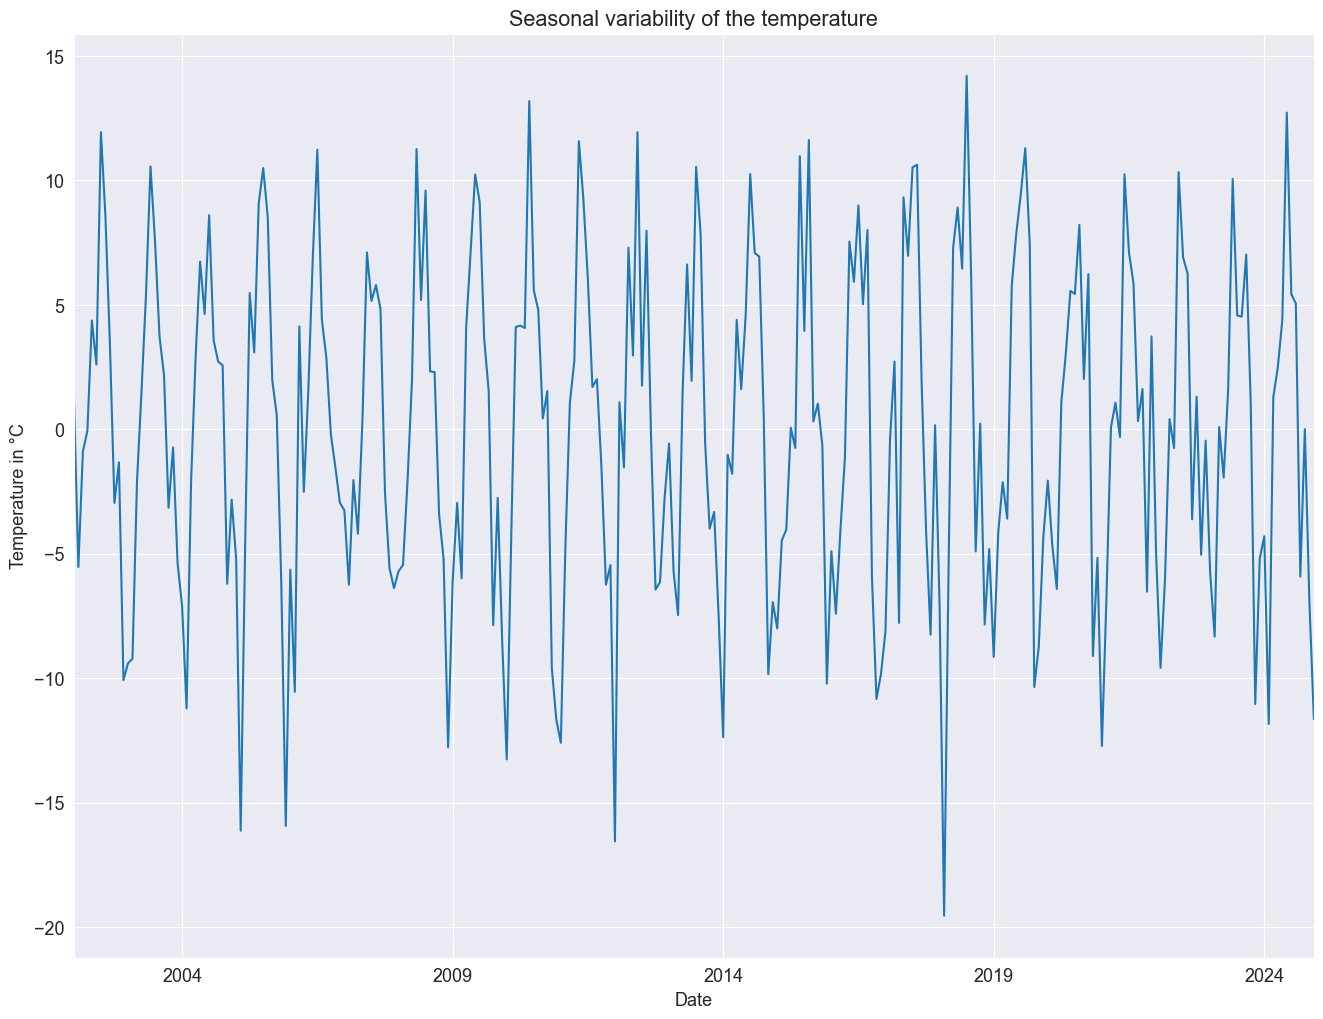

In [276]:
detrended.plot()
plt.title('Seasonal variability of the temperature')
plt.ylabel('Temperature in °C')

***


Let us investigate the remainder and review if the residuals are normally distributed.  


Text(0, 0.5, 'Temperature in °C')

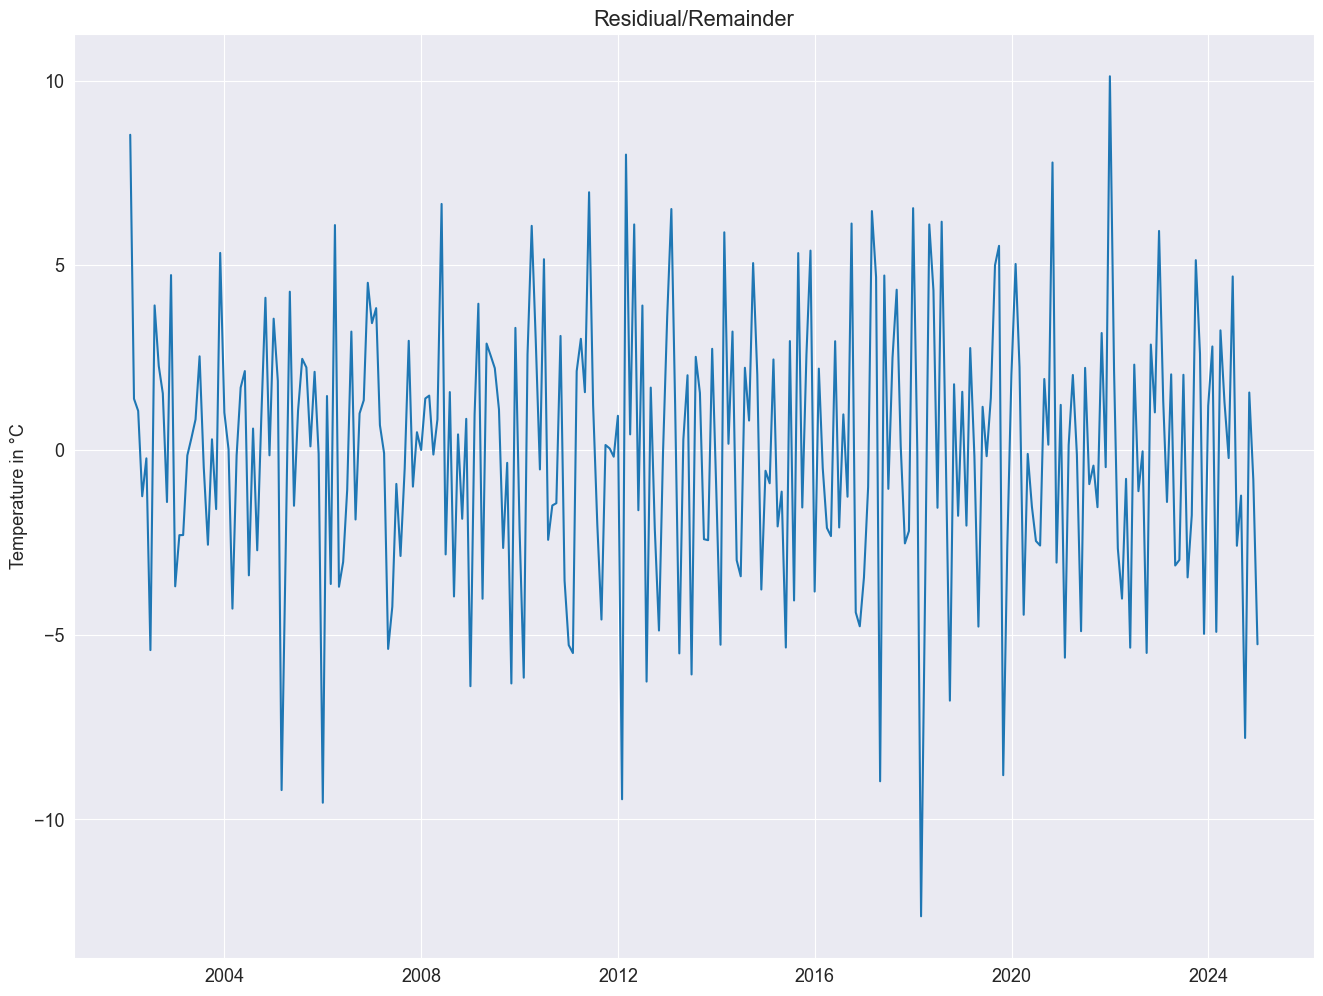

In [277]:
plt.plot(result.resid)
plt.title('Residiual/Remainder')
plt.ylabel('Temperature in °C')

#### Normality check of the residuals

Next, we check if the residuals are normally distributed to assure that the additive model was the right choice. 


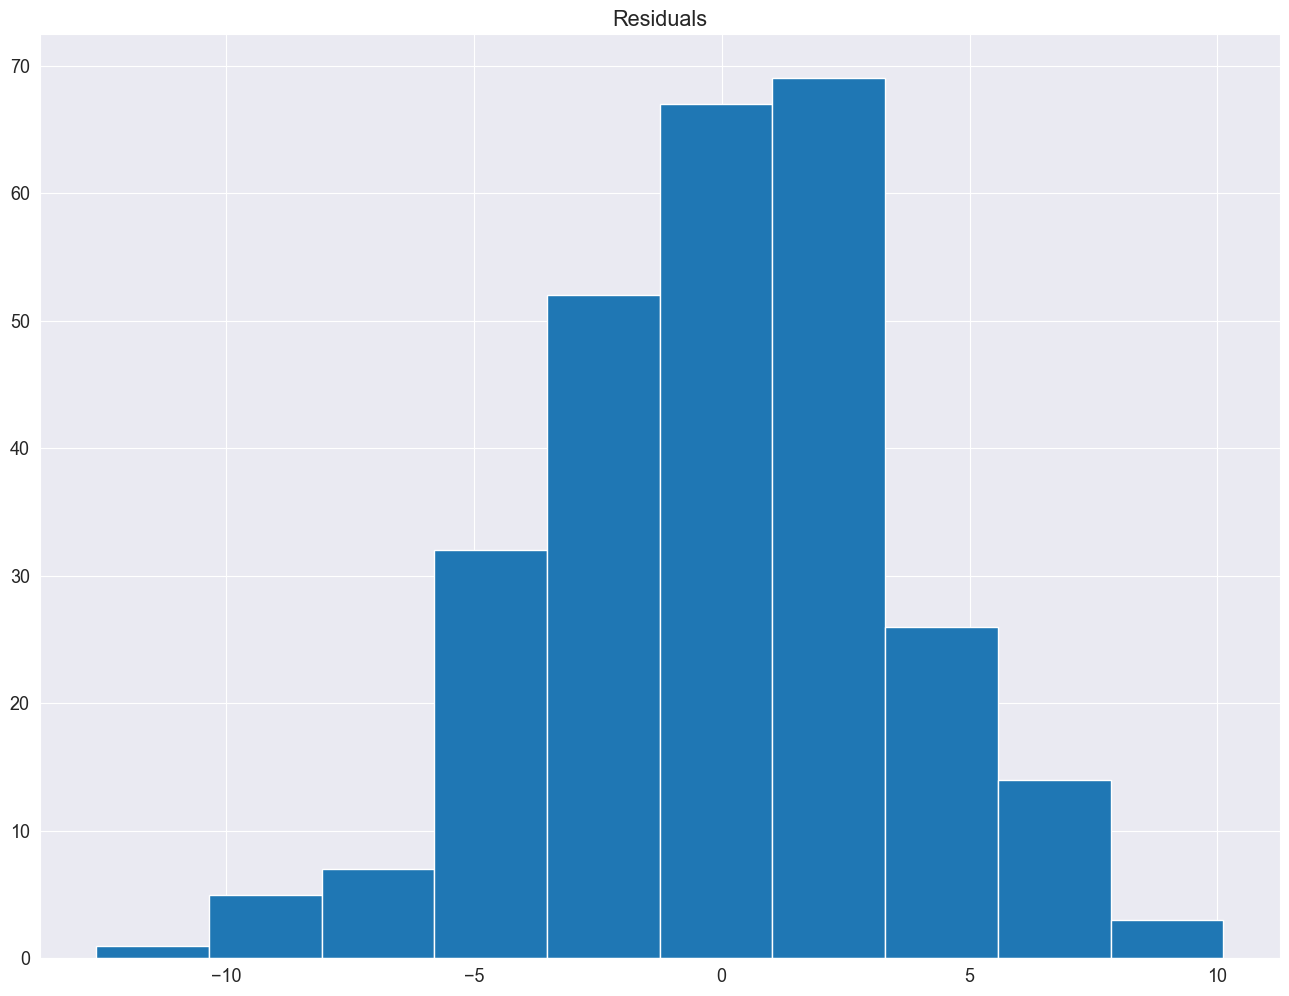

In [279]:
# histogram plot
pyplot.hist(result.resid)
pyplot.title('Residuals')
pyplot.show()

The residuals seem fairly well normally distributed. This means, that we considered an appropriate model. 

Additionally you can apply a [Shapiro–Wilk test](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test) and check for normality. 



In [280]:
from scipy.stats import shapiro

# Beispiel: Test auf Normalverteilung der Residuen
stat, p_value = shapiro(result.resid.dropna())
print("Shapiro-Wilk Teststatistik:", stat)
print("p-Wert:", p_value)

Shapiro-Wilk Teststatistik: 0.9945903420448303
p-Wert: 0.43669435381889343


The p-value of 0.44 is significantly greater than 0.05. This means that the null hypothesis of normal distribution of the residuals is not rejected—the residuals are therefore (statistically) normally distributed. This indicates that the model is suitable.